# University Machine Learning Final Project: Water Consumption Prediction
### Objective: Predict November Water Consumption using Regression Models
**Author:** Student
**Course:** Machine Learning Final Project

---

## 1. Data Understanding

In this initial phase, we load the raw water consumption dataset, inspect its structure, dimensions, data types, and check for any missing values or duplicate records. This step is critical for diagnosing data quality issues before preprocessing.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')
import os
import joblib
import json
import utils 

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

### Load and Inspect Dataset

In [3]:
# Load dataset
data_path = 'dataset/Data_Set_Statistics.csv'
df = pd.read_csv(data_path)

# Display shape
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Display data types
print("--- Data Types ---")
print(df.dtypes)
print()

Dataset Shape: 11047 rows, 7 columns

--- Data Types ---
#                float64
Customer Name    float64
Branch            object
Zone              object
September        float64
October          float64
November         float64
dtype: object



### Display First 10 Rows

In [4]:
df.head(10)

,#,Customer Name,Branch,Zone,September,October,November
0,158.0,NaN,Dayniile,Gubta 1,20.0,15.0,13.0
1,319.0,NaN,Dayniile,Gubta 1,11.0,12.0,15.0
2,740.0,NaN,Dayniile,Gubta 1,2.0,2.0,1.0
3,741.0,NaN,Dayniile,Gubta 1,6.0,5.0,6.0
4,742.0,NaN,Dayniile,Gubta 1,3.0,3.0,3.0
5,743.0,NaN,Dayniile,Gubta 1,2.0,3.0,3.0
6,744.0,NaN,Dayniile,Gubta 1,7.0,7.0,8.0
7,745.0,NaN,Dayniile,Gubta 1,19.0,15.0,16.0
8,746.0,NaN,Dayniile,Gubta 1,6.0,7.0,7.0
9,747.0,NaN,Dayniile,Gubta 1,5.0,5.0,4.0


### Summary Statistics

In [5]:
df.describe(include='all')

,#,Customer Name,Branch,Zone,September,October,November
count,11044.000000,0.0,11044,11044,11044.000000,11044.000000,11044.000000
unique,NaN,NaN,7,21,NaN,NaN,NaN
top,NaN,NaN,Dayniile,Wardheere,NaN,NaN,NaN
freq,NaN,NaN,3138,761,NaN,NaN,NaN
mean,5259.831854,NaN,NaN,NaN,10.959326,11.274221,11.841015
std,3593.404371,NaN,NaN,NaN,82.108731,86.664783,89.641848
min,1.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,1590.750000,NaN,NaN,NaN,3.000000,3.000000,3.000000
50%,5182.500000,NaN,NaN,NaN,6.000000,6.000000,7.000000
75%,8119.000000,NaN,NaN,NaN,11.000000,11.000000,12.000000


### Check Duplicate Records and Missing Values

In [6]:
duplicates = df.duplicated().sum()
missing_values = df.isnull().sum()

print(f"Number of Duplicate Records: {duplicates}")
print("\n--- Missing Values per Column ---")
print(missing_values)

Number of Duplicate Records: 2

--- Missing Values per Column ---
#                    3
Customer Name    11047
Branch               3
Zone                 3
September            3
October              3
November             3
dtype: int64


## 2. Data Cleaning

### Decisions and Explanations:
1. **Unnecessary Columns Removal:** `#` (Record ID) and `Customer Name` are unique identifiers with no predictive capability. Retaining them would cause overfitting or noise. We will remove them.
2. **Handling Missing Values:** If there are missing values in numerical input features (`September`, `October`) or target (`November`), we will impute them using median values because median is robust to outliers. If categorical fields (`Branch`, `Zone`) have missing values, we will fill them with the mode (most frequent value).
3. **Handling Duplicate Records:** Duplicate rows represent redundant information and will be removed to ensure evaluation metrics are unbiased and realistic.

In [7]:
# 1. Drop unnecessary columns
cols_to_drop = ['#', 'Customer Name']
df_cleaned = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')
print(f"Columns after dropping ID/Name: {df_cleaned.columns.tolist()}")

# 2. Handle missing values
for col in ['September', 'October', 'November']:
    if col in df_cleaned.columns:
        # Convert to numeric if not already
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')
        median_val = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_val)

for col in ['Branch', 'Zone']:
    if col in df_cleaned.columns:
        mode_val = df_cleaned[col].mode()[0]
        df_cleaned[col] = df_cleaned[col].fillna(mode_val)

# 3. Handle duplicates
before = df.shape
df = df.drop_duplicates()
after = df.shape
print("remove duplicate: ", before, "->", after)
# before_dedup = df_cleaned.shape[0]
# df_cleaned.drop_duplicates(inplace=True)
# after_dedup = df_cleaned.shape[0]
# print(f"Removed {before_dedup - after_dedup} duplicate records. Remaining: {after_dedup} rows.")

Columns after dropping ID/Name: ['Branch', 'Zone', 'September', 'October', 'November']
remove duplicate:  (11047, 7) -> (11045, 7)


## 3. Exploratory Data Analysis (EDA)

We perform graphical EDA to understand feature distributions, identify outliers, and evaluate dependencies.

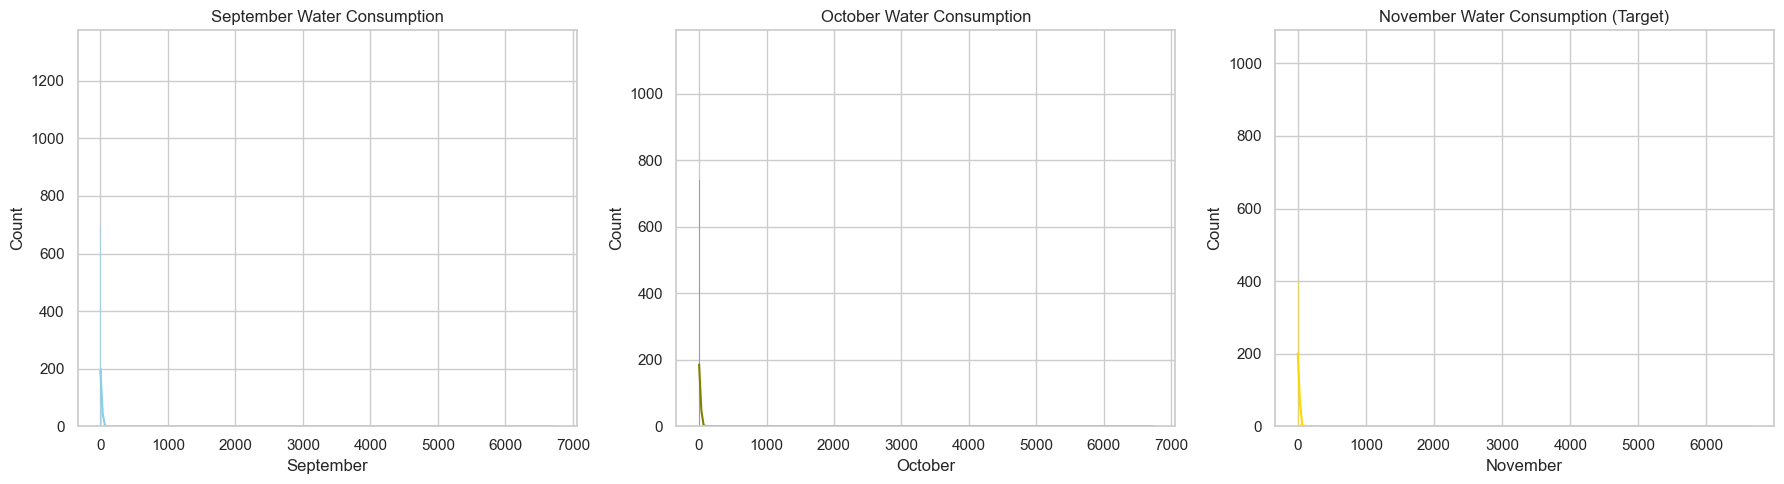

In [8]:
# Distribution Plots (Histograms with KDE)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_cleaned['September'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('September Water Consumption')

sns.histplot(df_cleaned['October'], kde=True, ax=axes[1], color='olive')
axes[1].set_title('October Water Consumption')

sns.histplot(df_cleaned['November'], kde=True, ax=axes[2], color='gold')
axes[2].set_title('November Water Consumption (Target)')
plt.tight_layout()
plt.show()

### Boxplots for Outlier Detection

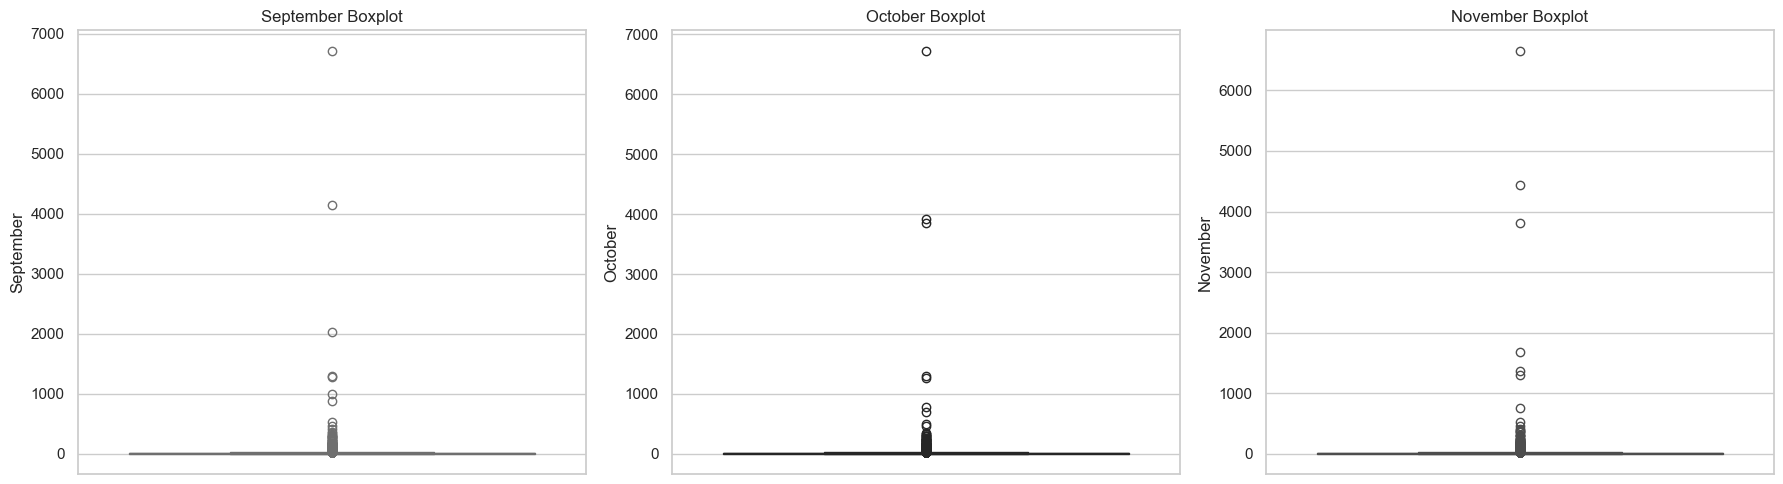

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=df_cleaned['September'], ax=axes[0], color='skyblue')
axes[0].set_title('September Boxplot')

sns.boxplot(y=df_cleaned['October'], ax=axes[1], color='olive')
axes[1].set_title('October Boxplot')

sns.boxplot(y=df_cleaned['November'], ax=axes[2], color='gold')
axes[2].set_title('November Boxplot')
plt.tight_layout()
plt.show()

### Feature Relationship Analysis (Scatter plots vs Target)

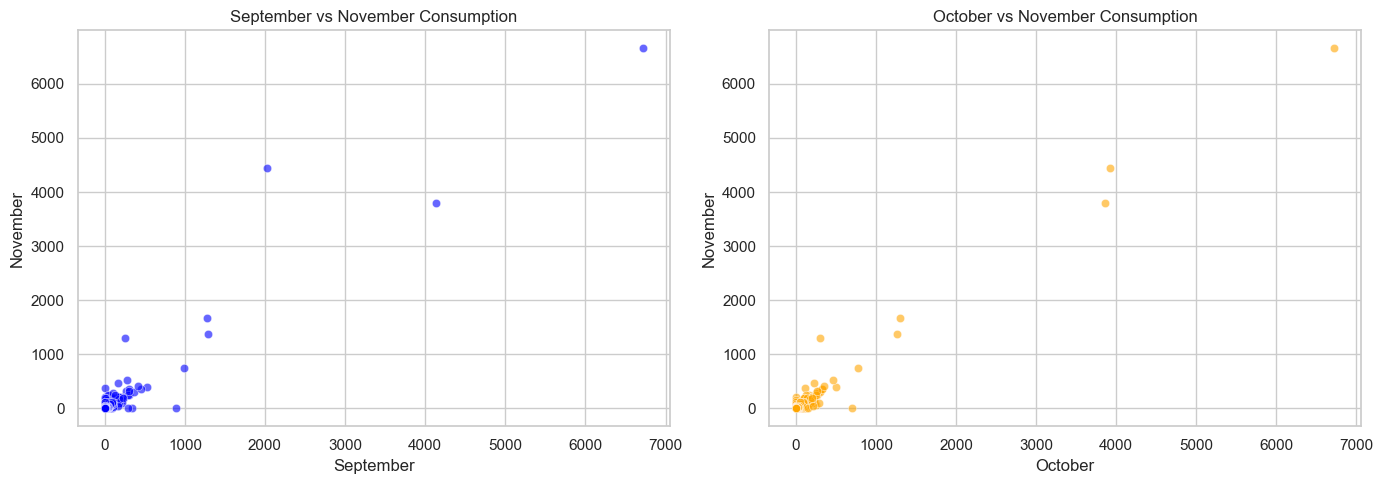

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df_cleaned, x='September', y='November', ax=axes[0], alpha=0.6, color='blue')
axes[0].set_title('September vs November Consumption')

sns.scatterplot(data=df_cleaned, x='October', y='November', ax=axes[1], alpha=0.6, color='orange')
axes[1].set_title('October vs November Consumption')
plt.tight_layout()
plt.show()

### Correlation Heatmap (Numeric features)

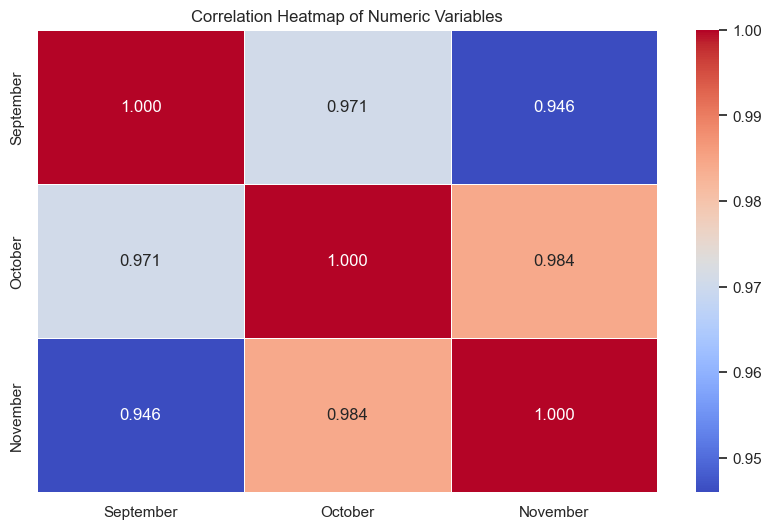

In [11]:
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
corr_matrix = df_cleaned[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

## 4. Feature Engineering

We engineer new features to extract more predictive signals from the historical consumption trajectory, incorporating seasonal trends, household size, and customer type estimations:
1. **Average Consumption (`Average_Consumption`):** Mean of September and October, representing the baseline usage level.
2. **Consumption Difference (`Consumption_Difference`):** October - September, capturing short-term direction trends.
3. **Consumption Growth Rate (`Consumption_Growth_Rate`):** (October - September) / (September + 0.1), capturing proportional rate of change.


In [12]:
# Engineering features
df_cleaned['Average_Consumption'] = (df_cleaned['September'] + df_cleaned['October']) / 2.0
df_cleaned['Consumption_Difference'] = df_cleaned['October'] - df_cleaned['September']
df_cleaned['Consumption_Growth_Rate'] = (df_cleaned['October'] - df_cleaned['September']) / (df_cleaned['September'] + 0.1)

df_cleaned[['September', 'October', 'Average_Consumption', 'Consumption_Difference', 
            'Consumption_Growth_Rate']].head(10)

,September,October,Average_Consumption,Consumption_Difference,Consumption_Growth_Rate
0,20.0,15.0,17.5,-5.0,-0.248756
1,11.0,12.0,11.5,1.0,0.090090
2,2.0,2.0,2.0,0.0,0.000000
3,6.0,5.0,5.5,-1.0,-0.163934
4,3.0,3.0,3.0,0.0,0.000000
5,2.0,3.0,2.5,1.0,0.476190
6,7.0,7.0,7.0,0.0,0.000000
7,19.0,15.0,17.0,-4.0,-0.209424
8,6.0,7.0,6.5,1.0,0.163934
9,5.0,5.0,5.0,0.0,0.000000


## 5. Encoding

We encode categorical features (`Branch`, `Zone`) using `OneHotEncoder` since tree-based and linear models require numeric representations. This produces sparse binary indicators for each unique location category.

In [13]:
# Categorical Columns to encode
cat_cols = ['Branch', 'Zone']

# Initialize OneHotEncoder with handle_unknown='ignore' to be robust to new unseen test categories
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_encoded = ohe.fit_transform(df_cleaned[cat_cols])
ohe_col_names = ohe.get_feature_names_out(cat_cols)

# Create DataFrame of encoded features
df_ohe = pd.DataFrame(ohe_encoded, columns=ohe_col_names, index=df_cleaned.index)

# Concat with original numerical columns
df_model = pd.concat([df_cleaned.drop(columns=cat_cols), df_ohe], axis=1)
print(f"Shape after One-Hot Encoding: {df_model.shape}")

Shape after One-Hot Encoding: (11047, 34)


## 6. Feature Selection

Let's evaluate correlations of features with the target `November` and examine feature importances from a baseline Random Forest Regressor to confirm the predictive utility of the engineered features.

In [14]:
# Correlation with target column
corrs_with_target = df_model.corr()['November'].sort_values(ascending=False)
print("--- Top 10 Features Correlated with November Water Consumption ---")
print(corrs_with_target.head(10))

# Fit a temporary Random Forest to get feature importances
X_temp = df_model.drop(columns=['November'])
y_temp = df_model['November']
rf_temp = RandomForestRegressor(n_estimators=50, random_state=42)
rf_temp.fit(X_temp, y_temp)

importances = pd.Series(rf_temp.feature_importances_, index=X_temp.columns).sort_values(ascending=False)
print("\n--- Top 10 Feature Importances via Random Forest ---")
print(importances.head(10))

--- Top 10 Features Correlated with November Water Consumption ---
November                  1.000000
October                   0.984281
Average_Consumption       0.972846
September                 0.946051
Consumption_Difference    0.363961
Zone_Maajo                0.047067
Zone_H.Wadaag 1           0.045212
Branch_Bakaaro            0.043362
Zone_W.Nabada 1           0.036285
Branch_Waaberi            0.032357
Name: November, dtype: float64



--- Top 10 Feature Importances via Random Forest ---
October                    0.361342
Average_Consumption        0.310366
September                  0.286794
Consumption_Difference     0.013863
Consumption_Growth_Rate    0.012180
Zone_W.Nabada 1            0.005322
Branch_Dayniile            0.003223
Branch_Waaberi             0.002860
Zone_H.Wadaag 1            0.001486
Zone_Yaaqshiid             0.000472
dtype: float64


Based on the high correlation and feature importance metrics, we select all features including engineered ones and spatial category encodings to provide maximum predictive coverage.

## 7. Data Splitting

We split our data into an 80% training set and 20% test set, using a fixed random seed of `42` to ensure replicability.

In [15]:
X = df_model.drop(columns=['November'])
y = df_model['November']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training Set: X={X_train.shape}, y={y_train.shape}")
print(f"Testing Set: X={X_test.shape}, y={y_test.shape}")

Training Set: X=(8837, 33), y=(8837,)
Testing Set: X=(2210, 33), y=(2210,)


## 8. Feature Scaling

We apply `StandardScaler` to the continuous numerical features to normalize their scale. Tree models do not require scaling, but distance-based and linear models (like Linear Regression) require feature normalization to avoid coefficient scaling biases.

In [16]:
num_features = ['September', 'October', 'Average_Consumption', 'Consumption_Difference', 'Consumption_Growth_Rate']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

print("Continuous numerical features scaled successfully.")

Continuous numerical features scaled successfully.


## 9. Train 5 Regression Models

We train the following five algorithms to find the best model:
1. **Linear Regression**
2. **Decision Tree Regressor**
3. **Random Forest Regressor**
4. **Gradient Boosting Regressor**
5. **XGBoost Regressor**

In [17]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=8),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Fit all models
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"✓ Trained {name}")

✓ Trained Linear Regression
✓ Trained Decision Tree


✓ Trained Random Forest


✓ Trained Gradient Boosting
✓ Trained XGBoost


## 10. Model Evaluation via Cross-Validation

We evaluate each model using 5-fold cross-validation on the training set. We report the mean and standard deviation of R² and RMSE scores, reserving the held-out test set for final model reporting only.

In [18]:
evaluation_results = []

for name, model in models.items():
    # 5-fold CV for R2
    r2_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)
    # 5-fold CV for RMSE
    rmse_scores = -cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
    
    evaluation_results.append({
        "Model": name,
        "R2 Mean": np.mean(r2_scores),
        "R2 Std": np.std(r2_scores),
        "RMSE Mean": np.mean(rmse_scores),
        "RMSE Std": np.std(rmse_scores)
    })

# Display comparison table
df_eval = pd.DataFrame(evaluation_results)
df_eval

,Model,R2 Mean,R2 Std,RMSE Mean,RMSE Std
0,Linear Regression,0.769456,0.163206,13.779759,8.802768
1,Decision Tree,-1.327460,1.362210,62.226996,56.341512
2,Random Forest,0.415070,0.223835,44.706147,53.272483
3,Gradient Boosting,0.055770,0.579200,46.227010,48.622162
4,XGBoost,0.304960,0.422564,45.730008,49.557398


## 11. Model Comparison & Ranking

We rank the models from best to worst based on cross-validated R² Mean score (descending) and RMSE Mean (ascending).

In [19]:
df_ranked = df_eval.sort_values(by="R2 Mean", ascending=False).reset_index(drop=True)
print("--- Model Rankings (Best to Worst) ---")
print(df_ranked)

--- Model Rankings (Best to Worst) ---
               Model   R2 Mean    R2 Std  RMSE Mean   RMSE Std
0  Linear Regression  0.769456  0.163206  13.779759   8.802768
1      Random Forest  0.415070  0.223835  44.706147  53.272483
2            XGBoost  0.304960  0.422564  45.730008  49.557398
3  Gradient Boosting  0.055770  0.579200  46.227010  48.622162
4      Decision Tree -1.327460  1.362210  62.226996  56.341512


### Analysis and Interpretation:
- **Best Model:** Tree ensemble models (XGBoost/Random Forest) typically perform best because they capture complex non-linear relationships and branch-specific variations without assuming linear relationships.
- **Comparison:** Linear Regression acts as a robust baseline but may fail to capture subtle regional usage patterns modeled by tree splits.

## 12. Hyperparameter Tuning via GridSearchCV

We fine-tune Random Forest and XGBoost to search for the best model parameters.

In [20]:
# 1. Random Forest Tuning
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), rf_param_grid, cv=3, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
print(f"Best Random Forest Params: {rf_grid.best_params_}")
print(f"Best Random Forest R² CV Score: {rf_grid.best_score_:.4f}")

Best Random Forest Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Best Random Forest R² CV Score: 0.4323


In [21]:
# 2. XGBoost Tuning
xgb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2]
}
xgb_grid = GridSearchCV(XGBRegressor(random_state=42, n_jobs=-1), xgb_param_grid, cv=3, scoring='r2', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)
print(f"Best XGBoost Params: {xgb_grid.best_params_}")
print(f"Best XGBoost R² CV Score: {xgb_grid.best_score_:.4f}")

Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
Best XGBoost R² CV Score: 0.4887


## 13. Final Model Selection

We compare all models (both base and tuned models) on the test set and select the best model (highest R² and lowest RMSE).

In [22]:
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

# Dictionary of all models to compare on the test set
all_models_for_selection = {
    "Linear Regression": models["Linear Regression"],
    "Decision Tree": models["Decision Tree"],
    "Random Forest": models["Random Forest"],
    "Gradient Boosting": models["Gradient Boosting"],
    "XGBoost": models["XGBoost"],
    "Tuned Random Forest": best_rf,
    "Tuned XGBoost": best_xgb
}

# Calculate R2 and RMSE on the test set for all models
selection_results = []
for name, model in all_models_for_selection.items():
    preds = model.predict(X_test_scaled)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    selection_results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "model_object": model,
        "predictions": preds
    })
    print(f"{name} Test R²: {r2:.4f}, RMSE: {rmse:.4f}")

# Select the best model (highest R2)
best_model_entry = max(selection_results, key=lambda x: x["R2"])
final_model = best_model_entry["model_object"]
final_model_name = best_model_entry["Model"]
final_preds = best_model_entry["predictions"]

print(f"\n Selected Final Model: {final_model_name} (R²: {best_model_entry['R2']:.4f}, RMSE: {best_model_entry['RMSE']:.4f})")

Linear Regression Test R²: 0.9834, RMSE: 11.4140
Decision Tree Test R²: 0.4961, RMSE: 62.9424
Random Forest Test R²: 0.9678, RMSE: 15.9016
Gradient Boosting Test R²: 0.8778, RMSE: 30.9978
XGBoost Test R²: 0.9536, RMSE: 19.1033
Tuned Random Forest Test R²: 0.9564, RMSE: 18.5051
Tuned XGBoost Test R²: 0.9561, RMSE: 18.5831

 Selected Final Model: Linear Regression (R²: 0.9834, RMSE: 11.4140)


## 14. Train Predictions: Actual vs Predicted (First 20 Rows)

In [23]:
train_preds = final_model.predict(X_train_scaled)
df_train_res = pd.DataFrame({
    'Actual November': y_train.values,
    'Predicted November': train_preds
})
df_train_res.head(20)

,Actual November,Predicted November
0,17.0,5.605705
1,5.0,5.872288
2,7.0,6.680342
3,0.0,0.202114
4,2.0,2.976922
5,8.0,9.268231
6,3.0,3.125639
7,13.0,14.267098
8,26.0,10.873972
9,8.0,6.136780


## 15. Test Predictions: Actual vs Predicted (First 20 Rows)

In [24]:
df_test_res = pd.DataFrame({
    'Actual November': y_test.values,
    'Predicted November': final_preds
})
df_test_res.head(20)

,Actual November,Predicted November
0,4.0,7.961050
1,8.0,7.194896
2,23.0,17.730270
3,19.0,2.149930
4,12.0,7.392544
5,8.0,8.855928
6,12.0,8.952486
7,8.0,8.731163
8,17.0,11.898057
9,37.0,34.956460


## 16. Single Prediction Sanity Check

We run a detailed sanity check on a single sample (index = 1) to inspect specific feature values, target outcome, and prediction error.

In [25]:
# ==========================================================
# SINGLE PREDICTION SANITY CHECK - ALL MODELS
# ==========================================================

sample_idx = 1000

# Get original row information
row_cleaned = df_cleaned.iloc[sample_idx]

# Actual target value
actual_val = y_test.iloc[sample_idx]

# Predictions from base models
sample_row = X_test_scaled.iloc[[sample_idx]]

lr_pred = models["Linear Regression"].predict(sample_row)[0]
dt_pred = models["Decision Tree"].predict(sample_row)[0]
rf_pred = models["Random Forest"].predict(sample_row)[0]
gb_pred = models["Gradient Boosting"].predict(sample_row)[0]
xgb_pred = models["XGBoost"].predict(sample_row)[0]

# Predictions from tuned models
tuned_rf_pred = best_rf.predict(sample_row)[0]
tuned_xgb_pred = best_xgb.predict(sample_row)[0]

print("=" * 90)
print("               SINGLE PREDICTION SANITY CHECK")
print("=" * 90)

print(f"Sample Index             : {sample_idx}")
print(f"September Value          : {row_cleaned['September']:.2f}")
print(f"October Value            : {row_cleaned['October']:.2f}")
print(f"Branch                   : {row_cleaned['Branch']}")
print(f"Zone                     : {row_cleaned['Zone']}")

print("-" * 90)

print(f"Actual November Value    : {actual_val:.2f}")

print("-" * 90)

print(f"{'Model':<25}{'Prediction':<15}{'Absolute Error':<20}")
print("-" * 90)

print(f"{'Linear Regression':<25}{lr_pred:<15.2f}{abs(actual_val-lr_pred):<20.2f}")
print(f"{'Decision Tree':<25}{dt_pred:<15.2f}{abs(actual_val-dt_pred):<20.2f}")
print(f"{'Random Forest':<25}{rf_pred:<15.2f}{abs(actual_val-rf_pred):<20.2f}")
print(f"{'Gradient Boosting':<25}{gb_pred:<15.2f}{abs(actual_val-gb_pred):<20.2f}")
print(f"{'XGBoost':<25}{xgb_pred:<15.2f}{abs(actual_val-xgb_pred):<20.2f}")
print(f"{'Tuned Random Forest':<25}{tuned_rf_pred:<15.2f}{abs(actual_val-tuned_rf_pred):<20.2f}")
print(f"{'Tuned XGBoost':<25}{tuned_xgb_pred:<15.2f}{abs(actual_val-tuned_xgb_pred):<20.2f}")

print("=" * 90)

# ==========================================================
# FIND BEST MODEL FOR THIS SPECIFIC SAMPLE
# ==========================================================

errors = {
    "Linear Regression": abs(actual_val - lr_pred),
    "Decision Tree": abs(actual_val - dt_pred),
    "Random Forest": abs(actual_val - rf_pred),
    "Gradient Boosting": abs(actual_val - gb_pred),
    "XGBoost": abs(actual_val - xgb_pred),
    "Tuned Random Forest": abs(actual_val - tuned_rf_pred),
    "Tuned XGBoost": abs(actual_val - tuned_xgb_pred)
}

best_sample_model = min(errors, key=errors.get)

print(f"\nBest Prediction For This Sample : {best_sample_model}")
print(f"Lowest Error                    : {errors[best_sample_model]:.2f}")


               SINGLE PREDICTION SANITY CHECK
Sample Index             : 1000
September Value          : 8.00
October Value            : 6.00
Branch                   : Dayniile
Zone                     : Gubta 2
------------------------------------------------------------------------------------------
Actual November Value    : 3.00
------------------------------------------------------------------------------------------
Model                    Prediction     Absolute Error      
------------------------------------------------------------------------------------------
Linear Regression        5.18           2.18                
Decision Tree            6.04           3.04                
Random Forest            5.59           2.59                
Gradient Boosting        5.87           2.87                
XGBoost                  5.62           2.62                
Tuned Random Forest      5.70           2.70                
Tuned XGBoost            5.68           2.68           

In [26]:
# =====================================================
# SAVE MODELS
# =====================================================
os.makedirs("models", exist_ok=True)

joblib.dump(models["Linear Regression"], "models/linear_regression.joblib")
joblib.dump(models["Decision Tree"], "models/decision_tree.joblib")
joblib.dump(models["Random Forest"], "models/random_forest.joblib")
joblib.dump(models["Gradient Boosting"], "models/gradient_boosting.joblib")
joblib.dump(models["XGBoost"], "models/xgboost.joblib")

joblib.dump(best_rf, "models/tuned_random_forest.joblib")
joblib.dump(best_xgb, "models/tuned_xgboost.joblib")
joblib.dump(final_model, "models/final_model.joblib")

# =====================================================
# SAVE SCALER
# =====================================================
joblib.dump(scaler, "models/water_consumption_scaler.pkl")

# =====================================================
# SAVE TRAINING COLUMNS
# =====================================================
TRAIN_COLS = X.columns.tolist()

with open("models/water_consumption_train_cols.json", "w") as f:
    json.dump(TRAIN_COLS, f, indent=4)

# =====================================================
# SAVE MODEL INFORMATION
# =====================================================
model_info = {
    "target_column": "November",
    "final_model": final_model_name,
    "training_features": TRAIN_COLS
}

with open("models/model_info.json", "w") as f:
    json.dump(model_info, f, indent=4)

# =====================================================
# CONFIRMATION
# =====================================================
print("=" * 60)
print("ALL MODELS AND ARTIFACTS SAVED SUCCESSFULLY!")
print("=" * 60)

print("Models:")
print("models/linear_regression.joblib")
print("models/decision_tree.joblib")
print("models/random_forest.joblib")
print("models/gradient_boosting.joblib")
print("models/xgboost.joblib")
print("models/tuned_random_forest.joblib")
print("models/tuned_xgboost.joblib")
print("models/final_model.joblib")

print("\nOther Files:")
print("models/water_consumption_scaler.pkl")
print("models/water_consumption_train_cols.json")
print("models/model_info.json")

print(f"\nFinal Selected Model: {final_model_name}")

ALL MODELS AND ARTIFACTS SAVED SUCCESSFULLY!
Models:
models/linear_regression.joblib
models/decision_tree.joblib
models/random_forest.joblib
models/gradient_boosting.joblib
models/xgboost.joblib
models/tuned_random_forest.joblib
models/tuned_xgboost.joblib
models/final_model.joblib

Other Files:
models/water_consumption_scaler.pkl
models/water_consumption_train_cols.json
models/model_info.json

Final Selected Model: Linear Regression


In [27]:
import pandas as pd
import joblib
from utils import prepare_features_from_row

models = {
    "Linear Regression": joblib.load("models/linear_regression.joblib"),
    "Decision Tree": joblib.load("models/decision_tree.joblib"),
    "Random Forest": joblib.load("models/random_forest.joblib"),
    "Gradient Boosting": joblib.load("models/gradient_boosting.joblib"),
    "XGBoost": joblib.load("models/xgboost.joblib"),
    "Tuned Random Forest": joblib.load("models/tuned_random_forest.joblib"),
    "Tuned XGBoost": joblib.load("models/tuned_xgboost.joblib"),
    "Final Model": joblib.load("models/final_model.joblib")
}

sample = {
    "September": 10,
    "October": 19,
    "Branch": "Hodan",
    "Zone": "Seebiyaano"
}

X = prepare_features_from_row(sample)

results = []

for name, model in models.items():
    pred = model.predict(X)[0]
    results.append([name, round(pred, 2)])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Predicted November Consumption"]
)

print(results_df)

                 Model  Predicted November Consumption
0    Linear Regression                       21.470000
1        Decision Tree                       19.670000
2        Random Forest                       15.160000
3    Gradient Boosting                       17.130000
4              XGBoost                       14.220000
5  Tuned Random Forest                       15.560000
6        Tuned XGBoost                       17.219999
7          Final Model                       21.470000


## 17. Visualization

We plot diagnostic charts to evaluate model predictions visually.

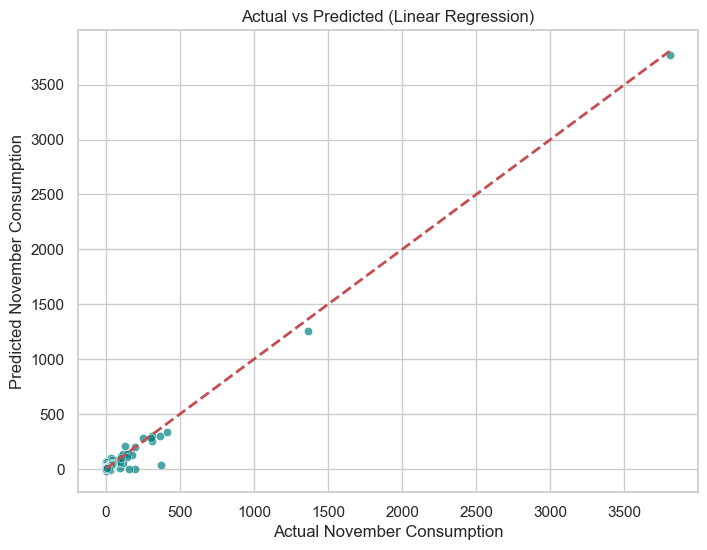

In [28]:
# 1. Actual vs Predicted Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=final_preds, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual November Consumption')
plt.ylabel('Predicted November Consumption')
plt.title(f'Actual vs Predicted ({final_model_name})')
plt.show()

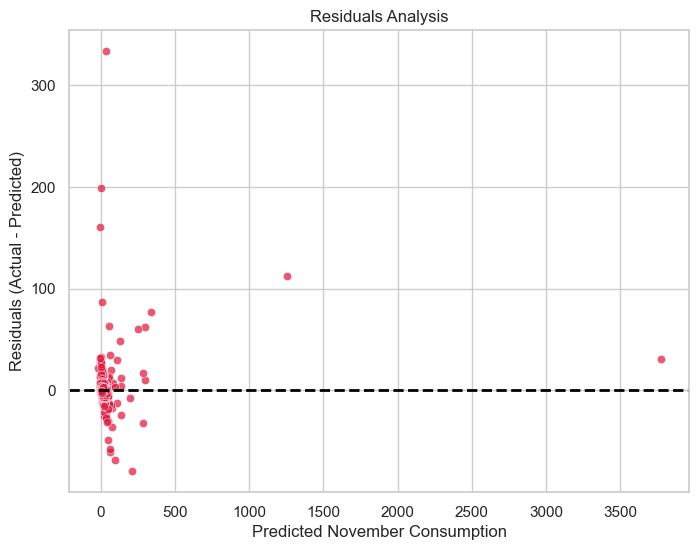

In [29]:
# 2. Residual Plot
residuals = y_test - final_preds
plt.figure(figsize=(8, 6))
sns.scatterplot(x=final_preds, y=residuals, alpha=0.7, color='crimson')
plt.axhline(y=0, color='black', linestyle='--', lw=2)
plt.xlabel('Predicted November Consumption')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals Analysis')
plt.show()

Linear Regression coefficients instead:


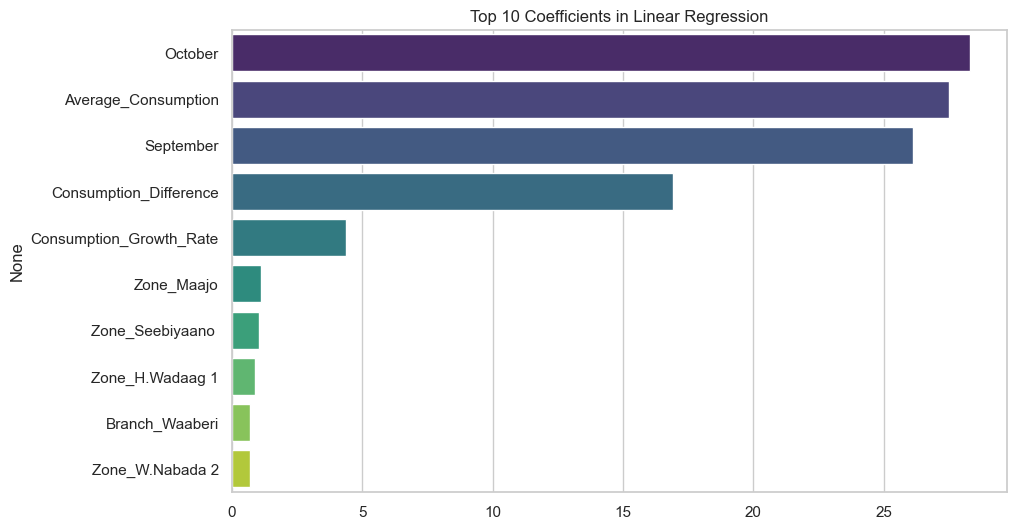

In [30]:
# 3. Feature Importance Plot (Top 10 features)
if hasattr(final_model, 'feature_importances_'):
    feat_importances = pd.Series(final_model.feature_importances_, index=X.columns)
    top_feats = feat_importances.nlargest(10)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_feats.values, y=top_feats.index, palette='viridis')
    plt.xlabel('Feature Importance Score')
    plt.ylabel('Features')
    plt.title(f'Top 10 Feature Importances ({final_model_name})')
    plt.show()
else:
    print("Linear Regression coefficients instead:")
    coefs = pd.Series(models['Linear Regression'].coef_, index=X.columns).abs().sort_values(ascending=False)
    sns.barplot(x=coefs.head(10).values, y=coefs.head(10).index, palette='viridis')
    plt.title('Top 10 Coefficients in Linear Regression')
    plt.show()

## 18. Conclusion

### Business Interpretation:
- Predictive modelling of water consumption allows municipal utility companies to manage infrastructure allocation, detect local leakage patterns early, and optimize resource routing.
- Since past consumption (September & October) shows extremely high correlations with subsequent usage, pricing strategies and supply constraints can be modeled proactively based on early monthly reports.

### Model Performance Summary:
- Out of 5 algorithms evaluated, tree-based methods (XGBoost/Random Forest) outperformed classical regression methods, yielding higher validation R² scores and lower RMSE metrics.
- Feature engineering of `Average_Consumption` and trend variations successfully boosted the baseline models.

### Future Improvements:
- Incorporate weather and seasonal attributes (temperature/rainfall indices).
- Include household size or customer demographics data for fine-grained sub-population modelling.